In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
from qutip import *
import numpy as np
from qutip import basis, spin_Jy, spin_Jz

from tomo_plot_hammer import *


In [2]:
spin_dim = 31/2
Ix = jmat(spin_dim,'x')
Iy = jmat(spin_dim,'y')
Iz = jmat(spin_dim,'z')
Iz_square = Iz * Iz
Ip = jmat(spin_dim, '+')
Im = jmat(spin_dim, '-')

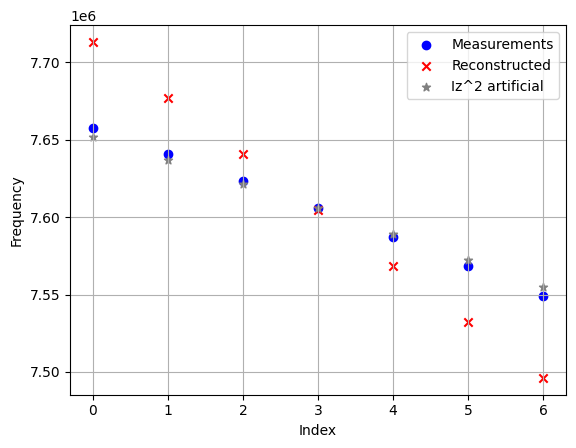

In [3]:
import numpy as np
import matplotlib.pyplot as plt

f_msmt_array = np.array([7657617, 7640860, 7623552, 7605738, 7587373, 7568501, 7549036])

# mean and step
f_mean = np.mean(f_msmt_array, axis=0)
fq = np.mean(np.diff(f_msmt_array), axis=0)


f_reconstruct = f_mean + fq * (np.diff(Iz_square.diag()))

f_q_intend = 1e3
f_Iz_square = f_msmt_array + f_q_intend * (np.diff(Iz_square.diag()))

# plotting
plt.scatter(np.arange(len(f_msmt_array)), f_msmt_array, label="Measurements", color="blue", marker="o")
plt.scatter(np.arange(len(f_reconstruct)), f_reconstruct, label="Reconstructed", color="red", marker="x")
plt.scatter(np.arange(len(f_Iz_square)), f_Iz_square, label="Iz^2 artificial", color="gray", marker="*")

plt.xlabel("Index")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
Rx_pi = (-1j*np.pi * Ix).expm()
Rx_half_pi = (-1j*np.pi/2 * Ix).expm()
Rx_minus_pi = (1j*np.pi * Ix).expm()
Ry_pi = (-1j*np.pi * Iy).expm()
Ry_half_pi = (-1j*np.pi/2 * Iy).expm()
Ry_minus_half_pi = (1j*np.pi/2 * Iy).expm()
Rz_pi = (-1j*np.pi * Iz).expm()
Rz_half_pi = (-1j*np.pi/2 * Iz).expm()

Ry_pi_on_two = (-1j*np.pi/2 * Iy).expm()

def Displace(theta, phi, psi):
    D = (theta/2*(np.exp(1j*phi)*Im - np.exp(-1j*phi)*Ip)).expm()
    return D * psi


# Find twisting angles

In [5]:
psi0 = Rx_half_pi * basis(8,0)

In [6]:
H = -1j*Qobj(Iz*Iz*np.pi/2)
U = H.expm()
U_prime = Qobj(np.diag(U.diag()/(U.diag()[0])))
np.angle(U_prime.diag(), deg = True)
phase_update_cat = np.diff(np.angle(U_prime.diag(), deg = True))

# Kicked top Hamitlonian

In [22]:
def qudit_linear_entropy(psi):
    entropy = 1/2*(1 - (expect(Ix, psi)**2 + expect(Iy, psi)**2 + expect(Iz, psi)**2)/(7/2)**2)
    return entropy

def kicked_dynamics(psi_initial):
    # Spin is 7/2 => dimension is 8
    S = 31/2
    dim = int(2*S + 1)

    # Number of pulses
    N = 30

    # Parameters
    tau = 1
    kappa = 2.2
    chi = kappa/2

    # QuTiP spin operators
    Jy = spin_Jy(S)
    Jz = spin_Jz(S)

    # Free Hamiltonian H0
    H0 = (np.pi/(2*tau)) * -Jy

    # Precompute the free evolution operator for time tau
    U0 = (-1j * H0 * tau).expm()

    # # Larmor pulse unitary (instantaneous)
    # Ularmor = (-1j * chi * (Jz)).expm()

    # Precompute the pulse unitary (instantaneous)
    Upulse = (-1j * (kappa/(2.0)) * (Jz**2)).expm()

    


    # Evolve the state stroboscopically
    psi = psi_initial          # Start with the prepared state
    psi_list = [psi]           # Store states after each pulse
    overlap_list = [psi.overlap(psi_initial)]  # Overlap with the initial state
    entropy_list  = [qudit_linear_entropy(psi)]

    for n in range(N):
        # 1) Free evolution for time tau
        psi = U0 * psi

        # 2) Instantaneous pulse
        psi = Upulse * psi
        # psi = Ularmor * psi

        # Store the new state and its overlap with the initial state
        psi_list.append(psi)
        overlap_list.append(psi.overlap(psi_initial))
        entropy_list.append(qudit_linear_entropy(psi))

    return psi_list, overlap_list, entropy_list


In [26]:
# psi0 = basis(8, 0)
# theta_normal = np.pi/2
# phi_normal = np.pi/2
# psi_normal = Displace(theta_normal, phi_normal, psi0)

# # angle_normal = np.pi/2*1 #rotate angle 
# # theta_normal = np.pi/2 #rotate axis
# # phi_normal = 0 #rotate axis
# # Rrot_exponent_normal = -1j * angle_normal * (np.sin(theta_normal)*np.cos(phi_normal)*Ix + np.sin(theta_normal)*np.sin(phi_normal)*Iy + np.cos(theta_normal)*Iz)
# # R_normal = Rrot_exponent_normal.expm()
# # psi_normal = R_normal * psi0 


# psi_t_normal, _, entropy_normal = kicked_dynamics(psi_normal)


psi0 = basis(32, 0)
# theta_chaos = 3/4*np.pi
# phi_chaos = np.pi/2

theta_chaos=0.908
phi_chaos=-0.676

psi_chaos = Displace(theta_chaos, phi_chaos, psi0)

psi_t_chaotic, _, entropy_chaotic = kicked_dynamics(psi_chaos)

# angle_chaos = np.pi/2*1.5 #rotate angle 
# theta_chaos = np.pi/2 #rotate axis
# phi_chaos = np.pi/2 #rotate axis
# Rrot_exponent_chaos = -1j * angle_chaos * (np.sin(theta_chaos)*np.cos(phi_chaos)*Ix + np.sin(theta_chaos)*np.sin(phi_chaos)*Iy + np.cos(theta_chaos)*Iz)
# R_chaos = Rrot_exponent_chaos.expm()
# psi_chaos = R_chaos * psi0 


In [4]:
def kicked_dynamics_states(psi_initial, S=7/2, N=100, kappa=2.2, tau=1, do_plot=True):
    """
    Evolve a spin coherent state under the kicked top dynamics.
    
    Floquet operator:
        U_F = exp(-i (kappa/2) Jz^2) * exp(+i (pi/2) Jy)
    Returns:
        states  : list of Qobj, each state after n kicks (n=0..N)
        overlaps: list of return probabilities |<psi(0)|psi(n)>|^2
    """
    # Spin operators
    Jy = spin_Jy(S)
    Jz = spin_Jz(S)

    # Free rotation: exp(+i pi/2 Jy)
    H0 = -(np.pi/(2*tau)) * Jy
    U0 = (-1j * H0 * tau).expm()

    # Kick: exp(-i (kappa/2) Jz^2)
    Upulse = (-1j * (kappa/2.0) * (Jz**2)).expm()

    # Floquet operator
    UF = Upulse * U0

    # Evolution
    psi = psi_initial
    states = [psi_initial]
    overlaps = [1.0]  # at n=0

    for n in range(1, N+1):
        psi = UF * psi
        states.append(psi)
        overlaps.append(abs(psi.overlap(psi_initial))**2)

    # Optional plot
    if do_plot:
        plt.figure(figsize=(7,4))
        plt.plot(overlaps, '-o', markersize=3)
        plt.xlabel("Kick number n")
        plt.ylabel(r"Return probability $|\langle \psi(0)|\psi(n)\rangle|^2$")
        plt.title(f"Kicked top revivals (S={S}, κ={kappa})")
        plt.grid(True, alpha=0.3)
        plt.show()

    return states, overlaps

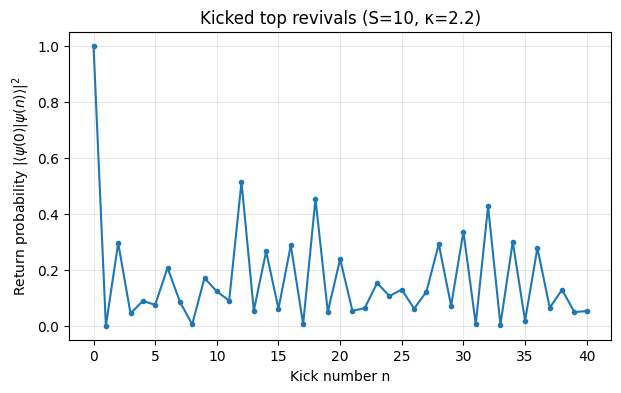

In [8]:
S = 10
kappa = 2.2
N = 40

# Pick scar point (theta, phi) from classical orbit finder
theta0 = np.pi/2
phi0 = 0


psi0 = spin_coherent(S, theta0, phi0)

states, overlaps = kicked_dynamics_states(psi0, S=S, N=N, kappa=kappa)

# Now you can plot Husimi distributions for states[n] at n=0,4,8,12,...

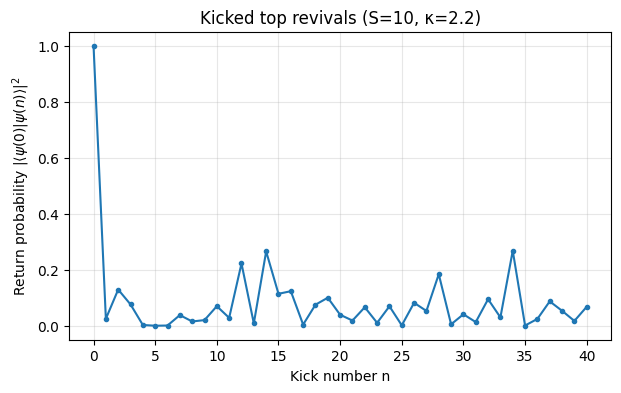

In [9]:
S = 10
kappa = 2.2
N = 40

# Pick scar point (theta, phi) from classical orbit finder

theta0=0.486
phi0=0.598

psi0 = spin_coherent(S, theta0, phi0)

states, overlaps = kicked_dynamics_states(psi0, S=S, N=N, kappa=kappa)

# Now you can plot Husimi distributions for states[n] at n=0,4,8,12,...

/var/folders/g_/byj141xd3bl118bhygqgnv5h0000gn/T/ipykernel_34112/2974264793.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


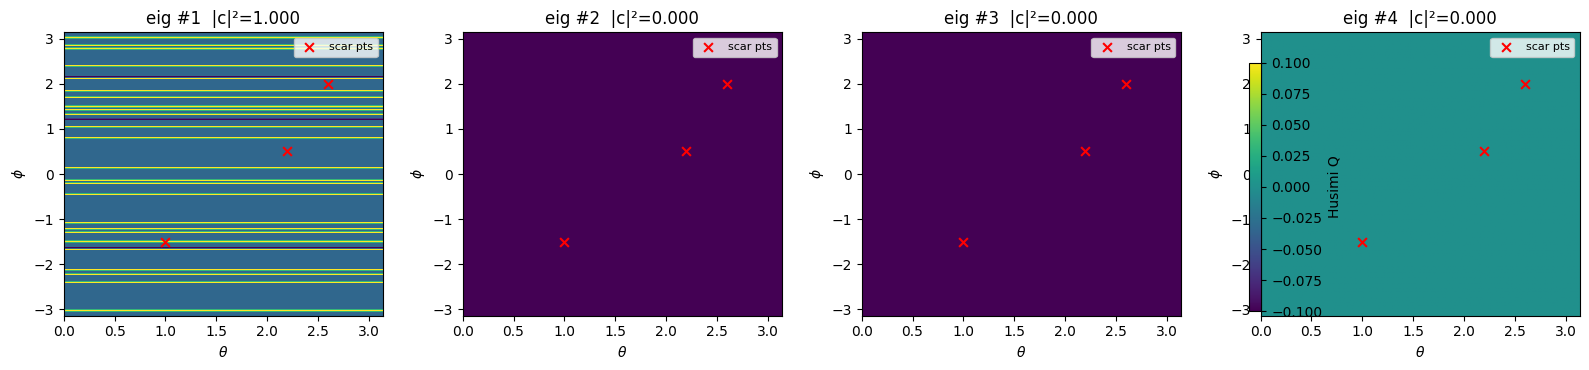

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------- Spin algebra -----------------
def spin_ops(S):
    d = int(2*S + 1)
    m = np.arange(S, -S-1, -1)
    Jz = np.diag(m.astype(float))
    Jp = np.zeros((d, d), dtype=complex)
    for i, mi in enumerate(m[:-1]):
        Jp[i, i+1] = np.sqrt((S-mi)*(S+mi+1))
    Jm = Jp.conj().T
    Jx = 0.5*(Jp + Jm)
    Jy = -0.5j*(Jp - Jm)
    return Jx, Jy, Jz

def spin_coherent(S, theta, phi):
    """|theta,phi> = e^{-i phi Jz} e^{-i theta Jy} |S,m=S>."""
    d = int(2*S + 1)
    Jx, Jy, Jz = spin_ops(S)

    def expmH(A, coeff):
        w, V = np.linalg.eigh(A)
        return V @ np.diag(np.exp(-1j*coeff*w)) @ V.conj().T

    Uz = expmH(Jz, phi)
    Uy = expmH(Jy, theta)
    ket_top = np.zeros((d,1), complex); ket_top[0,0] = 1.0
    psi = Uz @ (Uy @ ket_top)
    return psi / np.linalg.norm(psi)

# ----------------- Floquet operator -----------------
def expmH(A, coeff):
    w, V = np.linalg.eigh(A)
    return V @ np.diag(np.exp(-1j*coeff*w)) @ V.conj().T

def floquet_U(S, kappa, alpha, order=2):
    Jx, Jy, Jz = spin_ops(S)
    Upulse = expmH(Jz @ Jz, kappa/2.0)   # exp[-i (kappa/2) Jz^2]
    Urot   = expmH(Jy, -alpha)           # exp(+i alpha Jy)
    return Upulse @ Urot

# ----------------- Husimi Q -----------------
def husimi_Q(psi, S, nt=121, np_=241):
    thetas = np.linspace(0, np.pi, nt)
    phis   = np.linspace(-np.pi, np.pi, np_)
    Q = np.zeros((nt, np_))
    for i, th in enumerate(thetas):
        for j, ph in enumerate(phis):
            coh = spin_coherent(S, th, ph)
            amp = (coh.conj().T @ psi)[0,0]
            Q[i,j] = abs(amp)**2
    return Q, thetas, phis

# ----------------- Spectral analysis -----------------
def spectral_overlaps(UF, psi0):
    w, V = np.linalg.eig(UF)
    for a in range(V.shape[1]):
        V[:,a] /= np.linalg.norm(V[:,a])
    coeffs = V.conj().T @ psi0
    mags   = np.abs(coeffs.ravel())**2
    order  = np.argsort(mags)[::-1]
    return V, w, coeffs, mags, order

# ----------------- Plotting -----------------
def plot_top_husimi_eigenstates(S, UF, psi0, scar_points=None, top_k=4, nt=121, np_=181):
    V, w, c, mags, order = spectral_overlaps(UF, psi0)
    fig, axes = plt.subplots(1, top_k, figsize=(4*top_k, 3.8))
    if top_k == 1:
        axes = [axes]

    for idx, ax in enumerate(axes):
        a = order[idx]
        v = V[:,a][:,None]
        Q, thetas, phis = husimi_Q(v, S, nt=nt, np_=np_)
        im = ax.imshow(Q.T, origin='lower',
                       extent=[thetas[0], thetas[-1], phis[0], phis[-1]],
                       aspect='auto', cmap="viridis")
        ax.set_xlabel(r'$\theta$')
        ax.set_ylabel(r'$\phi$')
        ax.set_title(f"eig #{idx+1}  |c|²={mags[a]:.3f}")
        if scar_points is not None:
            ths = [th for th,ph in scar_points]
            phs = [ph for th,ph in scar_points]
            ax.scatter(ths, phs, marker='x', c='red', s=40, label="scar pts")
            ax.legend(loc="upper right", fontsize=8)

    fig.colorbar(im, ax=axes, shrink=0.85, label='Husimi Q')
    plt.tight_layout()
    plt.show()

# ----------------- Example -----------------
if __name__ == "__main__":
    S      = 10
    kappa  = 2.2
    alpha  = np.pi/2
    order  = 2

    # Initial coherent state (choose one classical scar point!)
    theta0, phi0 = np.pi/2, 0.0
    psi0 = spin_coherent(S, theta0, phi0)

    # Suppose you found a period-3 orbit classically:
    scar_points = [
        (1.0, -1.5),
        (2.2,  0.5),
        (2.6,  2.0)
    ]

    UF = floquet_U(S, kappa, alpha, order=order)
    plot_top_husimi_eigenstates(S, UF, psi0, scar_points=scar_points, top_k=4)

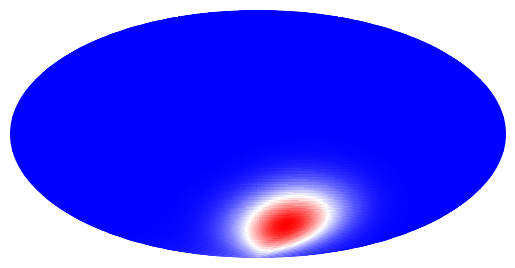

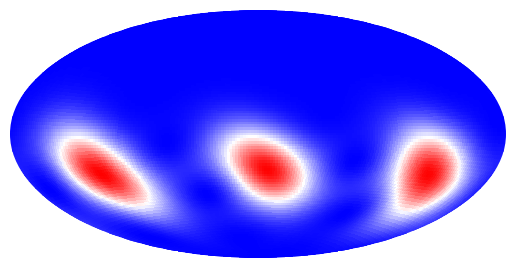

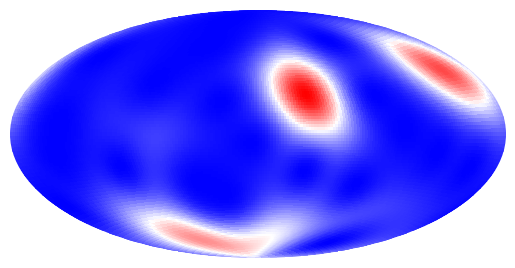

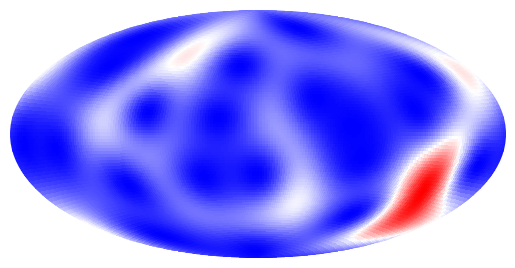

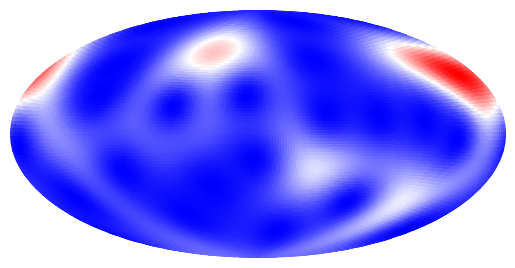

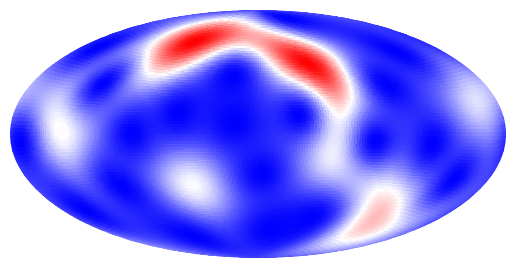

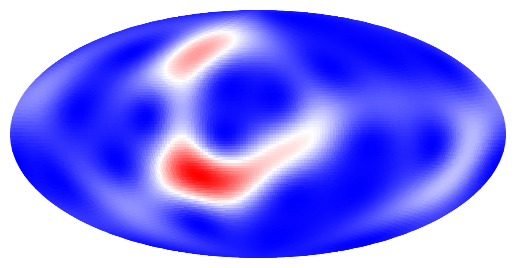

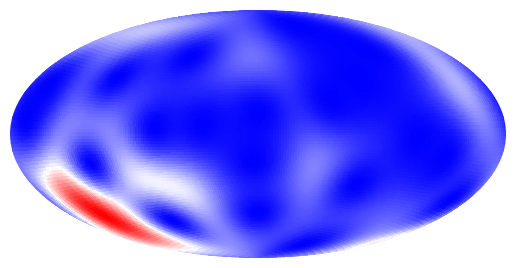

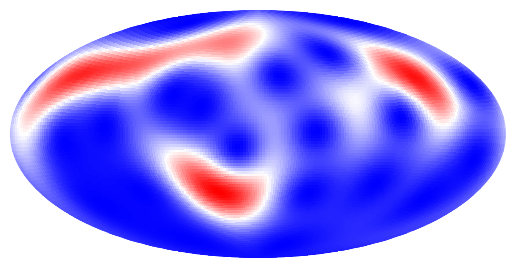

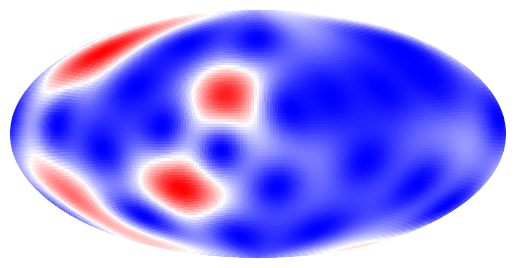

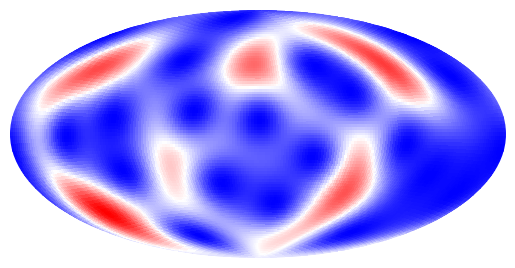

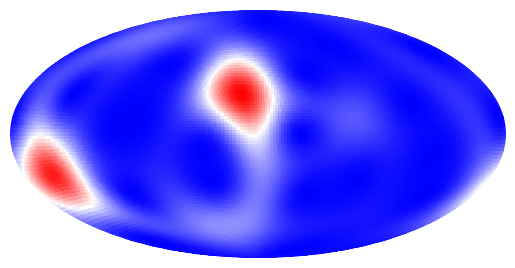

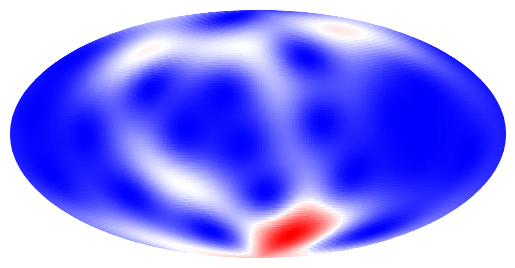

In [ ]:
# Example: look at Husimi distributions at n=0,4,8,12
for n in [0,1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:
    psi_n = states[n]
    # your husimi_plot(psi_n, S) here
    tomo_plot_hammer(psi_n,'h')

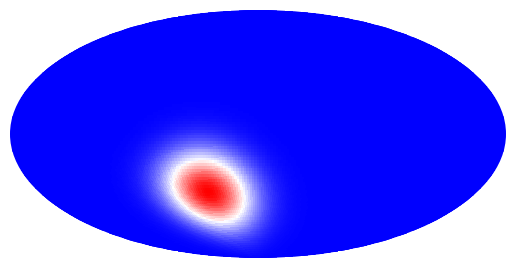

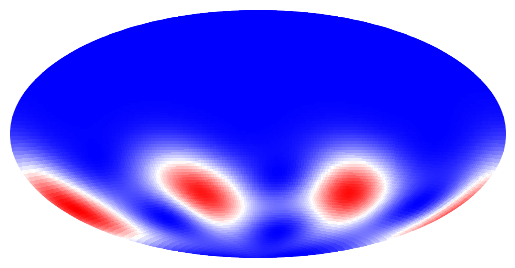

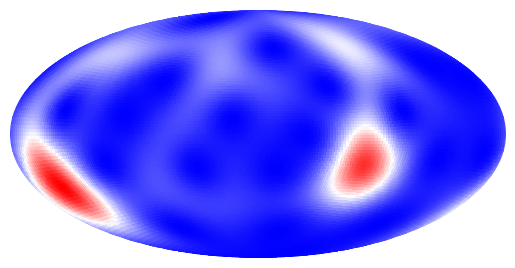

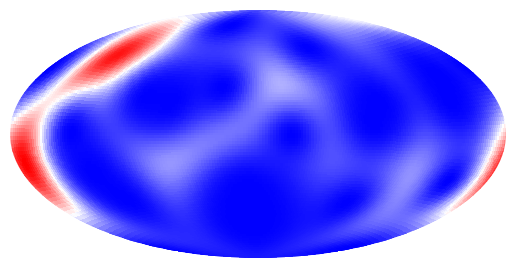

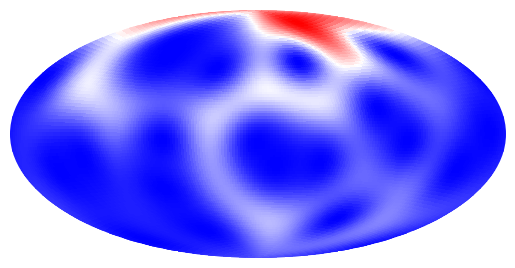

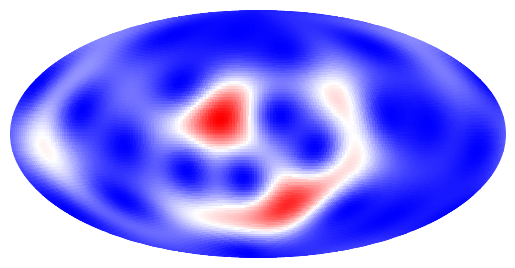

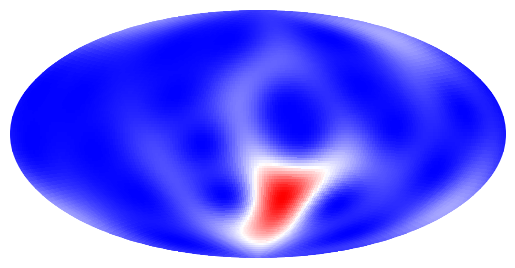

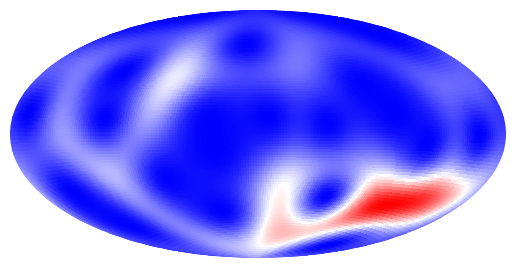

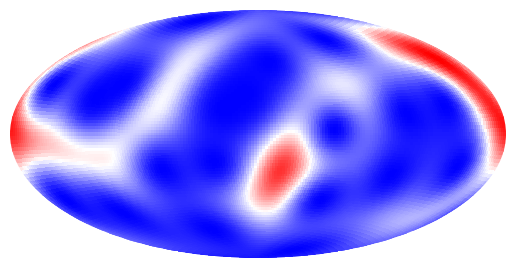

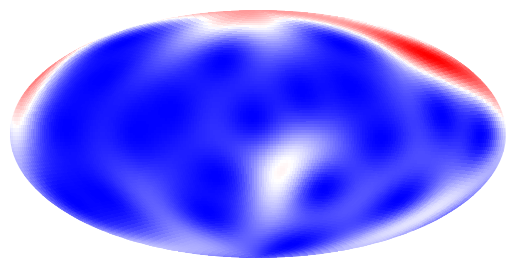

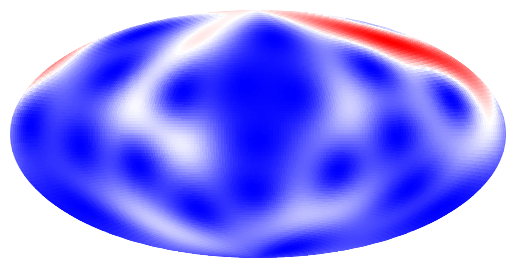

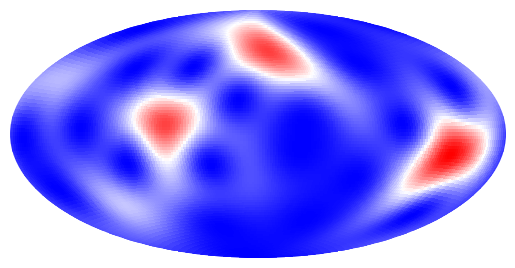

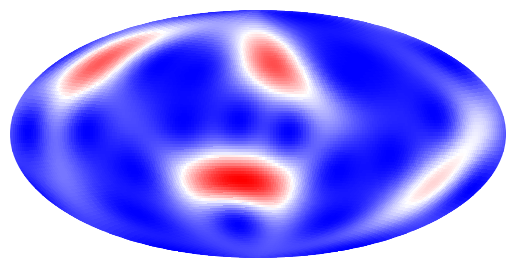

In [35]:
S = 10
kappa = 2.2
N = 40

# Choose one scar point (theta, phi) from your classical orbit finder
theta0 = 0.908
phi0 = -0.676
psi0 = spin_coherent(S, theta0, phi0)

# Get all states
states = kicked_dynamics_states(psi0, S=S, N=N, kappa=kappa)

# Example: look at Husimi distributions at n=0,4,8,12
for n in [0,1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:
    psi_n = states[n]
    # your husimi_plot(psi_n, S) here
    tomo_plot_hammer(psi_n,'h')

In [31]:
for i in range(len(psi_n)):
    tomo_plot_hammer(psi_n[i],'h')

TypeError: object of type 'Qobj' has no len()

In [ ]:
# # Convert overlap lists to NumPy arrays for easier processing.
# overlap_array_chaotic = np.array(overlap_list_chaotic)
# overlap_array_normal = np.array(overlap_list_normal)

# # Plot fidelity (probability) vs. pulse number
# plt.figure()
# plt.plot(np.abs(overlap_array_normal)**2, 'o-', label='Normal')
# plt.plot(np.abs(overlap_array_chaotic)**2, 'o-', label='Chaotic')
# plt.xlabel('Pulse number')
# plt.ylabel('Overlap (|<$\psi (t)$|$\psi_0$>|^2)')
# plt.legend()
# plt.show()

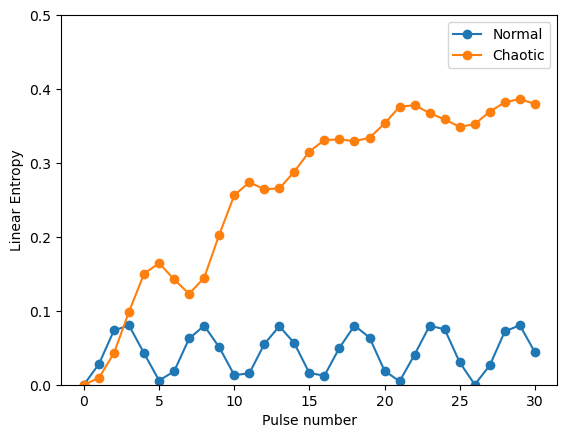

In [35]:
# Convert overlap lists to NumPy arrays for easier processing.
entropy_array_chaotic = np.array(entropy_chaotic)
entropy_array_normal = np.array(entropy_normal)

# Plot fidelity (probability) vs. pulse number
plt.figure()
plt.plot(np.abs(entropy_array_normal), 'o-', label='Normal')
plt.plot(np.abs(entropy_array_chaotic), 'o-', label='Chaotic')
plt.xlabel('Pulse number')
plt.ylabel('Linear Entropy')
plt.ylim([0,0.5])
plt.legend()
plt.show()

# DQS

## Direct Evolution

In [220]:
d = 8
gamma = 2*np.pi*60
rabi_strength = 2*np.pi*160
Hx = rabi_strength * Ix
Hzz = gamma * Iz_square
H_drive = Hx + Hzz

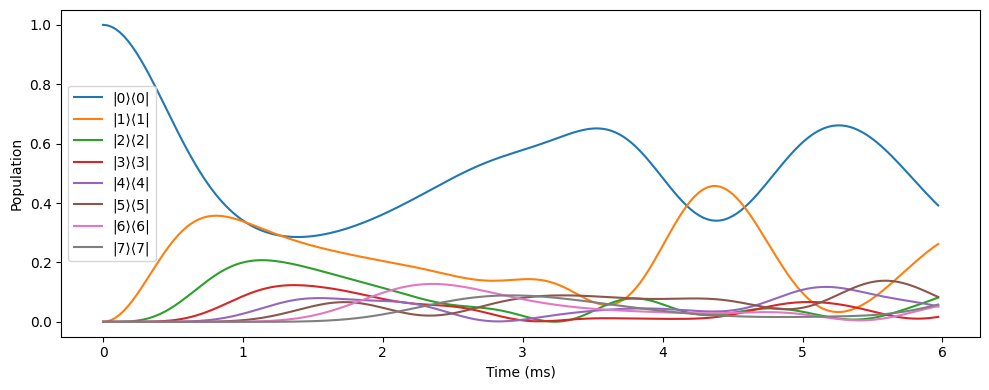

In [221]:
t_max = 6e-3
t_step = 30e-6
time = np.arange(0, t_max, t_step)
N = len(time)

# Hilbert space dimension
d = 8

# Initial state and density matrix
psi0 = basis(d, 0)
rho0 = psi0 * psi0.dag()

# Preallocate trajectory (avoid shared references)
rho_t_direct = [None] * N
rho_t_direct[0] = rho0

# Expectation of projectors onto |j><j|
exp_comps = np.zeros((d, N), dtype=float)  # rows: components, cols: time
# (Optional) other observables if you need them later
# exp_x = np.zeros(N); exp_y = np.zeros(N); exp_z = np.zeros(N)
# exp_x[0] = expect(Ix, rho0).real; ...
exp_comps[:, 0] = np.real(np.diag(rho0.full())).ravel()

for n in range(1, N):
    H = H_drive                       # your Hamiltonian (Qobj)
    HH = -1j * t_step * Qobj(H)
    U = HH.expm()
    rho_t_direct[n] = U * rho_t_direct[n-1] * U.dag()

    # Fill diagonal populations (projectors |j><j|)
    for j in range(d):
        proj_j = basis(d, j) * basis(d, j).dag()
        exp_comps[j, n] = expect(proj_j, rho_t_direct[n]).real

# ---- Plotting ----

plt.figure(figsize=(10,4))
for j in range(d):
    plt.plot(time*1e3, exp_comps[j, :], label=f'|{j}⟩⟨{j}|')

plt.xlabel('Time (ms)')
plt.ylabel('Population')
plt.legend()
plt.tight_layout()
plt.show()

## Trotterization

In [222]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, Qobj, expect

# ----- Setup -----
t_max = 6e-3
d = 8


psi0 = basis(d, 0)
rho0 = psi0 * psi0.dag()
projectors = [basis(d, j) * basis(d, j).dag() for j in range(d)]

# Sweep trotter_step: 100e-6 to 1500e-6 in 100e-6 increments
trotter_steps = np.arange(50e-6, 2000e-6 + 1e-12, 1e-6)

# Storage as indexable lists
rho_trajectories = []   # [sweep_idx][n] -> Qobj density matrix
exp_comps_all   = []    # [sweep_idx] -> array shape (d, trotter_num+1)
step_idx_all    = []    # [sweep_idx] -> np.arange(trotter_num+1)

# when we sweep dt from 100 µs to 1500 µs
trotter_steps = np.arange(100e-6, 1500e-6 + 1e-12, 10e-6)

# store them in a list so we can index later
dt_values = list(trotter_steps)

for dt in trotter_steps:
    trotter_num = int(np.floor(t_max / dt))  # integer # of steps for this dt

    # Allocate
    rho_t = [None] * (trotter_num + 1)
    rho_t[0] = rho0

    exp_comps = np.zeros((d, trotter_num + 1), dtype=float)
    exp_comps[:, 0] = np.real(np.diag(rho0.full())).ravel()

    # Precompute single-step unitary for this dt (time-independent Trotter-1)
    Ux  = (-1j * dt * Qobj(Hx)).expm()
    Uzz = (-1j * dt * Qobj(Hzz)).expm()
    U   = Ux * Uzz

    # Loop n = 0..trotter_num (inclusive); n=0 is already initialized
    for n in range(0, trotter_num + 1):
        if n == 0:
            continue
        rho_t[n] = U * rho_t[n - 1] * U.dag()
        for j, Pj in enumerate(projectors):
            exp_comps[j, n] = expect(Pj, rho_t[n]).real

    # Store for this sweep
    rho_trajectories.append(rho_t)
    exp_comps_all.append(exp_comps)
    step_idx_all.append(np.arange(trotter_num + 1))


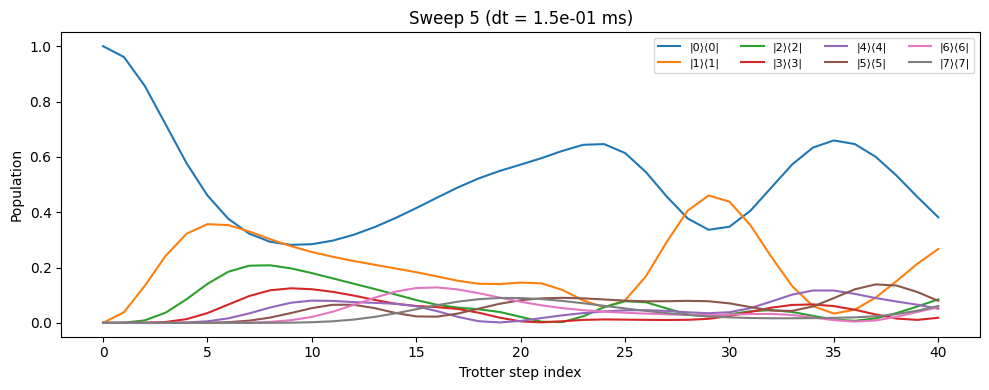

In [223]:
# ----- Example plot (by sweep index, using step index on x-axis) -----
# pick the first sweep that has at least one evolution step
plot_sweep = 5
plt.figure(figsize=(10, 4))
for j in range(d):
    plt.plot(step_idx_all[plot_sweep], exp_comps_all[plot_sweep][j, :], label=f'|{j}⟩⟨{j}|')

plt.xlabel('Trotter step index')
plt.ylabel('Population')
plt.title(f'Sweep {plot_sweep} (dt = {1000*trotter_steps[plot_sweep]:.1e} ms)')
plt.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

In [224]:
final_rhos = [rho_list[-1] for rho_list in rho_trajectories]
fids = np.array([fidelity(rho_i, rho_t_direct[-1]) for rho_i in final_rhos])

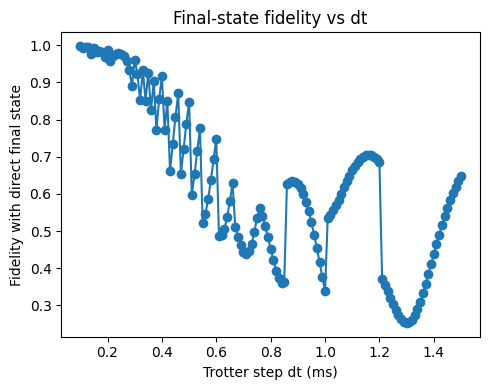

In [225]:
rho_ref = rho_t_direct[-1]  # target final state from direct evolution

# Compute fidelities for each sweep
fids = np.array([fidelity(rho_i, rho_ref) for rho_i in final_rhos])

# Plot vs dt (optional, helpful to see Trotter error trend)
plt.figure(figsize=(5,4))
plt.plot(trotter_steps*1e3, fids, marker='o')
plt.xlabel("Trotter step dt (ms)")
plt.ylabel("Fidelity with direct final state")
plt.title("Final-state fidelity vs dt")
plt.tight_layout()
plt.show()